In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np
import seaborn as sns
pd.set_option('display.max_rows', None)

In [2]:
train = pd.read_parquet('data/train.parquet')
test = pd.read_parquet('data/test.parquet')
val = pd.read_parquet('data/val.parquet')

In [3]:
x_cols = ['Attack ID', 'Avg source IP count', 'Detect count', 'Victim IP', 'Port number', 'Packet speed', 
          'Data speed', 'Avg packet len', 'Source IP count', 
          'Packet speed_normalized', 'Data speed_normalized', 'Avg packet len_normalized', 
          'total_seconds', 'weekday_number', 'time_of_day', 'IsWeekend', 'Start Hour', 'Sin_Hour', 
          'Cos_Hour', 'DayOfYear', 'Sin_DayOfYear', 'Cos_DayOfYear', 'Mean_DataSpeed', 'Std_DataSpeed', 
          'Min_DataSpeed', 'Max_DataSpeed', 'Mean_PacketSpeed', 'Min_PacketSpeed', 
          'Max_PacketSpeed', 'Mean_DetectCount', 'Std_DetectCount', 'Min_DetectCount', 'Max_DetectCount', 
          'VictimIP_Count', 'PortNumber_Count', 'AvgPacketLen_Mean', 'AvgPacketLen_Std', 
          'DataSpeed_PacketSpeed', 'PortFrequency', 'Std_DataSpeed_Replaced', 'Std_DetectCount_Replaced', 
          'AvgPacketLen_Std_Replaced', 'packet_Total', 'PacketSpeed_Per_Second',
          'DataSpeed_Per_TotalSeconds', 'AvgPacketLen_Per_TotalSeconds', 'Is_HTTP', 'Is_HTTPS', 
          'Is_FTP_Control', 'Is_FTP_Data', 'Is_SSH', 'Is_Telnet', 'Is_SMTP', 'Is_DNS', 'Is_POP3',
          'Is_IMAP', 'Is_DHCP', 'Is_SNMP', 'Is_LDAP', 'Is_LDAPS', 'Is_SMB_CIFS', 'Is_RDP', 'Is_SIP', 
          'Is_TFTP', 'Is_MySQL', 'Is_PostgreSQL', 'Is_Oracle', 'Is_HTTP_Alt_8080', 'Is_HTTP_Alt_8081',
          'Is_HTTP_Alt_80', 'Is_HTTPS_Alt_8443', 'Is_Syslog', 'Is_VNC', 'Is_IRC', 'Is_NTP', 'Is_Kerberos', 
          'Is_LDAP_Alt', 'Is_LDAPS_Alt', 'Is_RADIUS', 'Is_PPTP', 'Is_RTSP', 'Is_X11', 'Is_SNMP_Trap', 
          'Is_BGP', 'Is_IMAPS_Alt', 'Is_POP3S_Alt', 'Is_Telnet_SSL', 'Is_NNTP', 'Is_NNTPS', 'Is_LDAP_TLS', 
          'Is_AFS', 'Is_NFS', 'Is_SOCKS', 'Is_RSYNC', 'Is_CUPS', 'Is_TFTP_Alt', 'Is_Modbus', 'Is_CoAP', 
          'Is_MQTT', 'Is_AMQP', 'Is_Redis', 'Is_Memcached', 'Is_Elasticsearch', 'Is_Zookeeper', 
          'Is_Cassandra', 'Is_Docker', 'Is_Kubernetes', 'Is_SMB_Direct', 'Is_iSCSI', 'Is_AFP', 
          'Is_DHCPv6', 'Is_RIPng', 'Is_OSPF', 'Is_PPPoE', 'Is_L2TP', 'Is_GRE', 'Is_ESP', 'Is_AH',
          'PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5']

In [4]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=5, n_jobs=-1) 

train_labels = dbscan.fit_predict(train[x_cols])
test_labels = dbscan.fit_predict(test[x_cols])
val_labels = dbscan.fit_predict(val[x_cols])

# Store as feature
train['dbscan_cluster'] = train_labels
test['dbscan_cluster'] = test_labels
val['dbscan_cluster'] = val_labels

print(f"DBSCAN complete. Unique clusters found: {len(set(train_labels))}")
print(f"Noise points (label -1): {sum(train_labels == -1)}")

DBSCAN complete. Unique clusters found: 1
Noise points (label -1): 1820085


In [5]:
train.to_parquet('data/train.parquet', index=False)
test.to_parquet('data/test.parquet', index=False)
val.to_parquet('data/val.parquet', index=False)

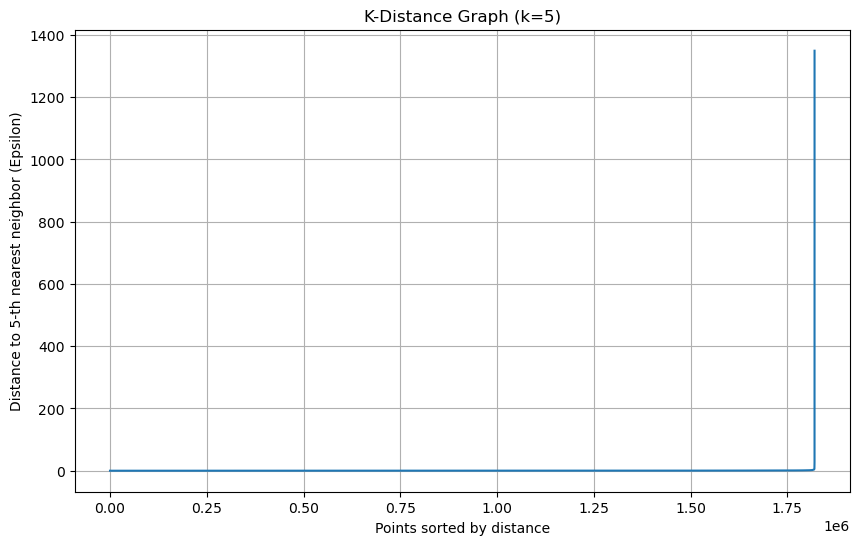

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

# 1. SCALING (Crucial for DBSCAN)
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train[x_cols])

# 2. Calculate Nearest Neighbors
# We use k=min_samples. 
k = 5 
nbrs = NearestNeighbors(n_neighbors=k).fit(train_scaled)
distances, indices = nbrs.kneighbors(train_scaled)

# 3. Sort and plot distances
# We take the distance to the k-th nearest neighbor (column index k-1)
sorted_distances = np.sort(distances[:, k-1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(sorted_distances)
plt.title(f"K-Distance Graph (k={k})")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {k}-th nearest neighbor (Epsilon)")
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# 1. SCALING
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train[x_cols])

# 2. Define search range
# Usually between 0.1 and 2.0 for scaled data
eps_values = np.arange(0.1, 1.5, 0.1) 
results = []

print("Starting Grid Search...")

for eps in eps_values:
    # min_samples usually kept constant or set to 2*n_features
    db = DBSCAN(eps=eps, min_samples=5, n_jobs=-1)
    labels = db.fit_predict(train_scaled)
    
    # Check number of clusters (ignoring noise -1)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    # We only calculate silhouette score if we have at least 2 clusters
    # and not everything is noise
    if n_clusters > 1 and n_noise < len(labels):
        score = silhouette_score(train_scaled, labels)
        results.append({'eps': eps, 'clusters': n_clusters, 'noise': n_noise, 'score': score})
        print(f"eps: {eps:.2f} | Clusters: {n_clusters} | Noise: {n_noise} | Score: {score:.4f}")
    else:
        print(f"eps: {eps:.2f} | Clusters: {n_clusters} | Noise: {n_noise} | Score: N/A")

# 3. Convert to DataFrame to see best results
results_df = pd.DataFrame(results)
if not results_df.empty:
    print("\nBest configurations sorted by Score:")
    print(results_df.sort_values(by='score', ascending=False).head())
else:
    print("\nNo valid multi-cluster configuration found in this range.")

Starting Grid Search...
eps: 0.10 | Clusters: 26212 | Noise: 560479 | Score: 0.0058
eps: 0.20 | Clusters: 28739 | Noise: 400002 | Score: 0.1387
eps: 0.30 | Clusters: 26333 | Noise: 315723 | Score: 0.1901
eps: 0.40 | Clusters: 25678 | Noise: 256927 | Score: 0.2122
